In [42]:
import matplotlib.pyplot as plt
import numpy as np

## 1. Create the grid using the following command (Do that only once).
fig, ax = CreateSudokuGrid()

In [43]:
def CreateSudokuGrid():
  fig, ax = plt.subplots(figsize=(3, 3))
  matcolors = [[64,64,64,1,1,1,64,64,64],
              [64,64,64,1,1,1,64,64,64],
              [64,64,64,1,1,1,64,64,64],
              [1,1,1,64,64,64,1,1,1],
              [1,1,1,64,64,64,1,1,1],
              [1,1,1,64,64,64,1,1,1],
              [64,64,64,1,1,1,64,64,64],
              [64,64,64,1,1,1,64,64,64],
              [64,64,64,1,1,1,64,64,64]]
  # imshow maps values to colors. 'cmap' defines the color scheme.
  im = ax.imshow(matcolors, cmap='Blues', vmax=255)
  # Add explicit grid lines for better cell separation
  # Set major grid lines at the boundaries between cells (e.g., 0.5, 1.5, ...)
  ax.set_xticks(np.arange(-0.5, 9, 1), minor=False)
  ax.set_yticks(np.arange(-0.5, 9, 1), minor=False)
  ax.set_xticklabels([" "]*10)
  ax.set_yticklabels([" "]*10)
  ax.grid(which='major', color='k', linestyle='-', linewidth=1) # 'k' for black lines
  ax.set_title("My Sudoku Grid")
  return fig, ax

## 2. Add the assignment to the grid using the following command
AddAssignment(ax, matrix_data)  // where ax is a pointer to the grid obtained when creating the grid,and matrix_data id a 2D array of values, e.g. [[1,2,3,4,0,6,0,8,9],[0,2,6,4,8,1,9,5,7], ...]
A zero value indicates an empty cell.

In [44]:
def AddAssignment(ax, matrix_data):
  for i in range(9):
    for j in range(9):
        if matrix_data[i][j] != 0:
          text = ax.text(j, i, matrix_data[i][j],
                       ha="center", va="center", color="k")
  return

## 3- Show the grid using the following command
plt.show()

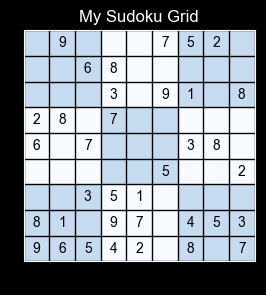

In [45]:
fig, ax = CreateSudokuGrid()
# create a sudoku puzzle in matrix_data
initial = [[0,9,0,0,0,7,5,2,0],
           [0,0,6,8,0,0,0,0,0],
           [0,0,0,3,0,9,1,0,8],
           [2,8,0,7,0,0,0,0,0],
           [6,0,7,0,0,0,3,8,0],
           [0,0,0,0,0,5,0,0,2],
           [0,0,3,5,1,0,0,0,0],
           [8,1,0,9,7,0,4,5,3],
           [9,6,5,4,2,0,8,0,7]]
AddAssignment(ax, initial)
plt.show()

In [46]:
def get_used_values(i, j, grid):
    row_values = set(v for v in grid[i] if v != 0)
    col_values = set(grid[k][j] for k in range(9) if grid[k][j] != 0)

    box_row = (i // 3) * 3
    box_col = (j // 3) * 3

    box_values = set(grid[box_row + r][box_col + c]
                    for r in range(3)
                    for c in range(3)
                    if grid[box_row + r][box_col + c] != 0)
    # Union all the values in rows, cols and box
    return row_values | col_values | box_values

In [47]:
def initialize_domains(grid):
    sudoku_domain = {1,2,3,4,5,6,7,8,9}
    domains = []
    for i in range(9):
        domains.append([0] * 9)

    for i in range(9):
        for j in range(9):
            # Exclude 0s from the empty cells
            if grid[i][j] != 0:
                domains[i][j] = {grid[i][j]}                      # Fixed Domain
            else:
                domains[i][j] = sudoku_domain - get_used_values(i, j, grid)             # Open Slots
    return domains

domains = initialize_domains(initial)
print(domains[0][0])
print(domains[0][1])

{1, 3, 4}
{9}


In [48]:
# Check if the assignment is complete
def is_complete(grid):
    for i in range(9):
        for j in range(9):
            if grid[i][j] == 0:
                return False
    return True
# Find the unassigned values
def select_unassigned(grid):
    for i in range(9):
        for j in range(9):
            if grid[i][j] == 0:
                return (i,j)
    return None
# If value(v) is a legal assignment
def is_consistent(v, i, j, grid):
    return v not in get_used_values(i, j, grid)

In [49]:
def backtrack(grid):
    sudoku_domain = {1,2,3,4,5,6,7,8,9}
    if is_complete(grid):
        return grid
    (i,j) = select_unassigned(grid)
    for v in sudoku_domain:
        if is_consistent(v, i, j, grid):
            grid[i][j] = v
            result = backtrack(grid)
            if result is not None:
                return result
            grid[i][j] = 0
    return None

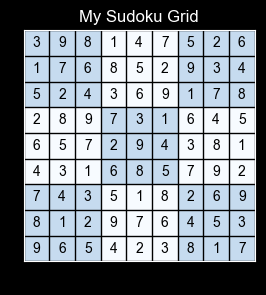

In [50]:
solution = backtrack(initial)
if solution:
    fig, ax = CreateSudokuGrid()
    AddAssignment(ax, solution)
    plt.show()
else:
    print("No solution!")

## AC-3 with inference

In [51]:
def get_neighbors(i, j):
    neighbors = set()
    # Same row different columns
    for c in range(9):
        if c!= j:
            neighbors.add((i,c))
    # Same column, different rows
    for r in range(9):
        if r != i:
            neighbors.add((r,j))
    # Box rows and cols
    box_row = (i // 3) * 3
    box_col = (j // 3) * 3
    for r in range(3):
        for c in range(3):
            if (box_row + r, box_col + c) != (i,j):
                    neighbors.add((box_row + r, box_col + c))
    return neighbors

In [52]:
def revise(Xi, Xj, domains):
    revised = False
    xi_row, xi_col = Xi
    xj_row, xj_col = Xj

    for x in set(domains[xi_row][xi_col]):
        # If no value in Xj's domain is different from x
        if domains[xj_row][xj_col] == {x}:          # Xj is forced to x
            domains[xi_row][xi_col].remove(x)       # Xi can't also be x
            revised = True
    return revised

In [53]:
from collections import deque

def AC_3(domains, i, j):
    # Initialize queue with arcs for all neighbors of (i,j)
    queue = deque([(neighbor, (i,j)) for neighbor in get_neighbors(i,j)])

    while queue:
        Xi, Xj = queue.popleft()
        if revise(Xi, Xj, domains):
            xi_row, xi_col = Xi
            if len(domains[xi_row][xi_col]) == 0:
                return False
            # Add arcs from the neighbors of Xi
            for Xk in get_neighbors(xi_row, xi_col):
                if Xk != Xj:
                    queue.append((Xk, Xi))
    return True

In [54]:
import copy

def backtrack_AC_3(grid, domains):
    if is_complete(grid):
        return grid

    (i,j) = select_unassigned(grid)

    for v in domains[i][j]:                 # Use domain values
        if is_consistent(v, i, j, grid):
            grid[i][v] = v
            domains[i][j] = {v}

            domains_copy = copy.deepcopy(domains)
            if AC_3(domains, i, j):
                result = backtrack_AC_3(grid, domains)
                if result is not None:
                    return result
            # undo everything
            grid[i][j] = 0
            domains = domains_copy          # Restore the domains
    return None

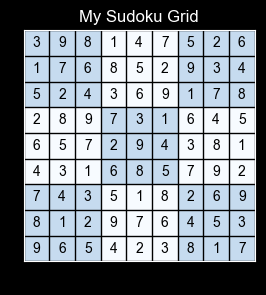

In [55]:
solution_AC_3 = backtrack_AC_3(initial, domains)

if solution_AC_3:
    fig, ax = CreateSudokuGrid()
    AddAssignment(ax, solution_AC_3)
    plt.show()
else:
    print("No solution!")